# Chapter-4 uniaxial dielectrics as Bruggeman/IMG constituents: can they reach the Dyakonov–Voigt threshold?

We take the uniaxial materials tabulated in Chapter 4 of *Electromagnetic Surface Waves* —

| material | $\varepsilon_s$ (ordinary) | $\varepsilon_t$ (extraordinary) | intrinsic $\gamma=\varepsilon_t/\varepsilon_s$ |
|---|---|---|---|
| E7 liquid crystal | 2.31 | 2.98 | 1.29 |
| YVO$_4$ | 3.97 | 4.91 | 1.24 |
| rutile | 7.02 | 8.70 | 1.24 |
| calomel | 3.88 | 7.02 | 1.81 |

— and use them as **constituents** of a particulate composite, homogenized with the Bruggeman
formalism (`bruggeman.eps_hcm`, extended below to uniaxial constituents) and cross-checked
against Incremental Maxwell Garnett. Constituent optic axes are aligned with the HCM
symmetry axis $z$, so the composite stays uniaxial and the JPCM dyadic equations split into
$t$/$z$ components (module `bruggeman_aniso.py`).

Two scenarios, as requested:
1. **uniaxial + isotropic** constituent (e.g. calomel or rutile particles in a fluid/void host);
2. **both constituents uniaxial** (e.g. calomel particles in an E7 host) — *does the extra
   intrinsic anisotropy let us use less elongated particles?*

**Headline results (details below):**
* A lossless DV wave at a uniaxial/isotropic interface *requires* $\gamma_{\rm HCM}>3$
  (from inequalities (2.35)). A rigorous, microstructure-independent Wiener bound shows the
  best chapter pair (rutile + void) tops out at $\gamma\le2.77$ — **no all-dielectric mixture
  of these materials can support a DV wave, for any particle shape or fraction.**
* Constituent uniaxiality is nevertheless a *big* lever on the shape requirement: at fixed
  target $\gamma$, uniaxial inclusions (and/or a uniaxial host) cut the required aspect ratio
  severalfold; a calomel-in-E7 composite reaches with **spheres** what its isotropized twin
  cannot reach with needles.
* Restricting to **real, strictly positive permittivities**, DV *is* reachable — but not with
  the chapter materials, and not within the paper's shaped-particles-in-spherical-host scheme.
  An isotropic pair of contrast $\gtrsim18$ (e.g. $20:1$) in a **columnar morphology** (both
  phases co-elongated, CTF-like, AR $\gtrsim13$) crosses $\gamma=3$ and yields admissible DV
  solutions with $\psi_{\rm DV}\approx8\text{--}17^\circ$.


In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from scipy.optimize import brentq

from bruggeman import eps_hcm
from bruggeman_aniso import (eps_hcm_aniso, img_hcm_aniso, gamma_wiener_bound)

# --- Chapter-4 uniaxial materials: (eps_s ordinary, eps_t extraordinary), optic axis -> z
M = {"E7": (2.31, 2.98), "YVO4": (3.97, 4.91), "rutile": (7.02, 8.70), "calomel": (3.88, 7.02)}
isoize = lambda p: (2*p[0] + p[1])/3          # orientation-averaged 'isotropized' twin

# --- DV machinery from the companion notebook: eq (2.29) root + inequalities (2.35)
def psi_DV(es, et, eB):
    if not (eB > es): return np.nan
    def G(d):
        c = 1.0/np.tan(np.deg2rad(d))**2
        rad = es*(es + (es-eB)*c)
        return np.nan if rad < 0 else (2*es*(eB+es)+(es-eB)*(es+et)*c)+2*(es+eB)*np.sqrt(rad)
    clo = 2*es*(es+eB)/((eB-es)*(es+et)); chi = es/(eB-es)
    if clo <= 0 or chi <= 0: return np.nan
    a, b = sorted(np.degrees(np.arctan(1.0/np.sqrt([clo, chi])))); a, b = a+1e-7, b-1e-7
    if a >= b: return np.nan
    Ga, Gb = G(a), G(b)
    if not (np.isfinite(Ga) and np.isfinite(Gb)) or Ga*Gb > 0: return np.nan
    try:    return brentq(G, a, b, xtol=1e-10)
    except Exception: return np.nan

def admissible_2_35(es, et, eB, psi_deg):
    p = np.deg2rad(psi_deg)
    return (es > eB*np.cos(p)**2) and ((et - es) > 2*eB) and (eB > es)

# sanity: the aniso solver reduces to the scalar solver for isotropic pairs
a = eps_hcm(1.5+0.1j, 5+0.6j, 0.3, "dt_spheroid", kappa=0.9, alpha=0.3)
b = eps_hcm_aniso((1.5+0.1j,)*2, (5+0.6j,)*2, 0.3, "dt_spheroid", kappa=0.9, alpha=0.3)
print("aniso solver reduces to bruggeman.eps_hcm:", np.allclose(a, b))


aniso solver reduces to bruggeman.eps_hcm: True


## Why $\gamma>3$ is *necessary* for a lossless DV wave

Inequalities (2.35) demand $\varepsilon_B>\varepsilon_s$ **and** $\varepsilon_t-\varepsilon_s>2\varepsilon_B$
(with $\varepsilon_s=\varepsilon_t^{\rm HCM}$, $\varepsilon_t=\varepsilon_z^{\rm HCM}$ when the HCM's
symmetry axis lies in the interface plane). Chaining them:

$$\varepsilon_t \;>\; \varepsilon_s + 2\varepsilon_B \;>\; 3\varepsilon_s
\qquad\Longrightarrow\qquad \gamma=\frac{\varepsilon_z^{\rm HCM}}{\varepsilon_t^{\rm HCM}}>3 .$$

So before solving any dispersion equation we can ask a cheaper question: *can the composite's
$\gamma$ exceed 3 at all?* For aligned two-phase media with real positive constituents this is
bounded **independently of microstructure** by the Wiener bounds,
$\varepsilon_z \le f\,\varepsilon_z^{A}+(1{-}f)\,\varepsilon_z^{B}$ (arithmetic) and
$\varepsilon_t \ge \big[f/\varepsilon_t^{A}+(1{-}f)/\varepsilon_t^{B}\big]^{-1}$ (harmonic), so

$$\gamma \;\le\; \max_f\;\Big(f\varepsilon_z^{A}+(1{-}f)\varepsilon_z^{B}\Big)
\Big(\tfrac{f}{\varepsilon_t^{A}}+\tfrac{1-f}{\varepsilon_t^{B}}\Big).$$

Bruggeman and IMG estimates always sit *inside* this bound, so if the bound is $<3$ the case is closed.

pair                                gamma_bound   f*      verdict
--------------------------------------------------------------------
E7+void                              1.444      0.629   DV impossible
YVO4+void                            1.854      0.540   DV impossible
rutile+void                          2.773      0.518   DV impossible
calomel+void                         2.558      0.591   DV impossible
iso-E7(2.53)+void                    1.232      0.500   DV impossible
iso-YVO4(4.28)+void                  1.629      0.500   DV impossible
iso-rutile(7.58)+void                2.428      0.500   DV impossible
iso-calomel(4.93)+void               1.782      0.500   DV impossible
calomel+E7 (both uniaxial)           1.822      0.867   DV impossible
rutile+E7 (both uniaxial)            1.680      0.485   DV impossible
rutile+calomel (both uniaxial)       1.809      0.000   DV impossible

rutile: host eps must be < 0.904 for the bound to reach 3  (vacuum = 1  ->  unreachable)
calom

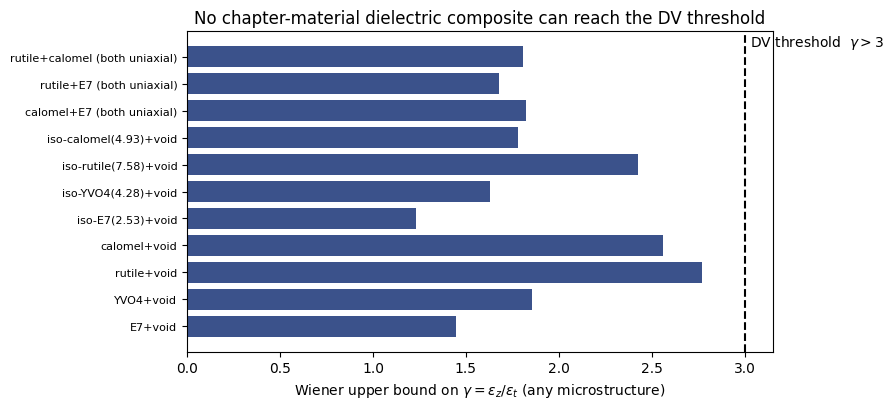

In [2]:
rows = []
print(f"{'pair':34s}  gamma_bound   f*      verdict")
print("-"*68)
combos  = [(m, f"{m}+void", M[m], 1.0) for m in M]
combos += [(f"iso-{m}", f"iso-{m}({isoize(M[m]):.2f})+void", isoize(M[m]), 1.0) for m in M]
combos += [("cal+E7", "calomel+E7 (both uniaxial)", M["calomel"], M["E7"]),
           ("rut+E7", "rutile+E7 (both uniaxial)",  M["rutile"],  M["E7"]),
           ("rut+cal","rutile+calomel (both uniaxial)", M["rutile"], M["calomel"])]
for key, label, eA, eB in combos:
    g, f = gamma_wiener_bound(eA, eB)
    rows.append((label, g))
    print(f"{label:34s}  {g:6.3f}      {f:.3f}   {'DV conceivable' if g>3 else 'DV impossible'}")

# how low would the host permittivity have to go for the *bound* to reach 3?
print()
for m in ("rutile", "calomel"):
    lo, hi = 0.01, 2.0
    for _ in range(60):
        mid = 0.5*(lo+hi)
        lo, hi = (mid, hi) if gamma_wiener_bound(M[m], mid)[0] > 3 else (lo, mid)
    print(f"{m}: host eps must be < {lo:.3f} for the bound to reach 3  (vacuum = 1  ->  unreachable)")
print(f"(two isotropic constituents need contrast > 5+2*sqrt(6) = {5+2*np.sqrt(6):.2f})")

fig, ax = plt.subplots(figsize=(9, 4.2))
labels, vals = zip(*rows)
ax.barh(range(len(rows)), vals, color=["#3b528b" if v < 3 else "#d1495b" for v in vals])
ax.axvline(3, color="k", ls="--", lw=1.5); ax.text(3.03, len(rows)-0.6, "DV threshold  $\\gamma>3$")
ax.set_yticks(range(len(rows))); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel(r"Wiener upper bound on $\gamma=\varepsilon_z/\varepsilon_t$ (any microstructure)")
ax.set_title("No chapter-material dielectric composite can reach the DV threshold")
plt.tight_layout(); plt.show()


**Verdict for scenario 1 *and* 2 with purely dielectric constituents:** even the loosest bound
peaks at 2.77 (rutile + void) — and to reach it you would need vacuum inclusions shaped as
perfect laminae. The host permittivity required for the bound to touch 3 is below 1 for every
chapter material, i.e. **no passive dielectric partner exists**. Mixing two chapter uniaxials
is *worse* than mixing with void, because the second dielectric raises $\varepsilon_t$ (kills the
contrast) more than its own anisotropy adds to $\varepsilon_z$.

A broad Bruggeman scan ($f_A\in[0.05,0.95]$, $\alpha\in[0.02,1]$, $\kappa\to1$, several DV
partners $\varepsilon_B$) confirms zero admissible DV solutions — consistent with the bound.

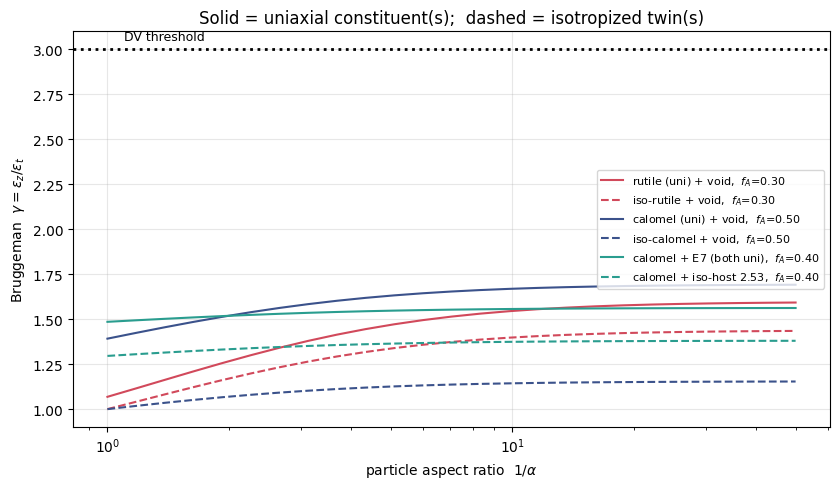

In [3]:
# Bruggeman gamma vs particle elongation (full prolate spheroids, kappa -> 1)
def gam(eA, eB, f, al):
    et, ez = eps_hcm_aniso(eA, eB, f, "dt_spheroid", kappa=0.999, alpha=al)
    return (ez/et).real

AR = np.geomspace(1, 50, 25)               # aspect ratio = 1/alpha
cases = [
    ("rutile (uni) + void,  $f_A$=0.30",        M["rutile"],          1.0,            0.30, "#d1495b", "-"),
    ("iso-rutile + void,  $f_A$=0.30",          isoize(M["rutile"]),  1.0,            0.30, "#d1495b", "--"),
    ("calomel (uni) + void,  $f_A$=0.50",       M["calomel"],         1.0,            0.50, "#3b528b", "-"),
    ("iso-calomel + void,  $f_A$=0.50",         isoize(M["calomel"]), 1.0,            0.50, "#3b528b", "--"),
    ("calomel + E7 (both uni),  $f_A$=0.40",    M["calomel"],         M["E7"],        0.40, "#2a9d8f", "-"),
    ("calomel + iso-host 2.53,  $f_A$=0.40",    M["calomel"],         isoize(M["E7"]),0.40, "#2a9d8f", "--"),
]
fig, ax = plt.subplots(figsize=(8.5, 5))
for lab, eA, eB, f, col, ls in cases:
    ax.plot(AR, [gam(eA, eB, f, 1/r) for r in AR], color=col, ls=ls, label=lab)
ax.axhline(3, color="k", ls=":", lw=2); ax.text(1.1, 3.05, "DV threshold", fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("particle aspect ratio  $1/\\alpha$")
ax.set_ylabel(r"Bruggeman  $\gamma=\varepsilon_z/\varepsilon_t$")
ax.set_title("Solid = uniaxial constituent(s);  dashed = isotropized twin(s)")
ax.legend(fontsize=8, loc="center right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## Does constituent uniaxiality buy less-elongated particles? Yes — dramatically.

Every solid curve sits well above its dashed (isotropized) twin, and the vertical offset is
worth orders of magnitude in aspect ratio because the curves saturate. Reading off required
shapes at fixed targets:

In [4]:
def alpha_needed(eA, eB, f, target):
    g = lambda a: gam(eA, eB, f, a) - target
    if g(1.0) >= 0:   return 1.0        # spheres already suffice
    if g(0.005) < 0:  return np.nan     # unreachable at any elongation
    return brentq(g, 0.005, 1.0, xtol=1e-5)

print("required aspect ratio 1/alpha (1.0 = spheres suffice, nan = unreachable):\n")
print("rutile-based, void host, fA=0.30:")
for t in (1.3, 1.4, 1.5):
    au, ai = alpha_needed(M["rutile"], 1.0, .3, t), alpha_needed(isoize(M["rutile"]), 1.0, .3, t)
    print(f"  gamma={t}:  uniaxial rutile AR={1/au if au==au else np.nan:5.1f}   iso-rutile AR={1/ai if ai==ai else np.nan:5.1f}")
print("\ncalomel inclusions, fA=0.40 — both-uniaxial (E7 host) vs uniaxial+isotropic host (2.53):")
for t in (1.35, 1.45, 1.50, 1.55):
    auu = alpha_needed(M["calomel"], M["E7"], .4, t)
    aui = alpha_needed(M["calomel"], isoize(M["E7"]), .4, t)
    print(f"  gamma={t}:  cal+E7  AR={1/auu if auu==auu else np.nan:5.1f}   cal+iso  AR={1/aui if aui==aui else np.nan:5.1f}")


required aspect ratio 1/alpha (1.0 = spheres suffice, nan = unreachable):

rutile-based, void host, fA=0.30:
  gamma=1.3:  uniaxial rutile AR=  2.3   iso-rutile AR=  3.9
  gamma=1.4:  uniaxial rutile AR=  3.4   iso-rutile AR= 10.3
  gamma=1.5:  uniaxial rutile AR=  6.3   iso-rutile AR=  nan

calomel inclusions, fA=0.40 — both-uniaxial (E7 host) vs uniaxial+isotropic host (2.53):
  gamma=1.35:  cal+E7  AR=  1.0   cal+iso  AR=  3.0
  gamma=1.45:  cal+E7  AR=  1.0   cal+iso  AR=  nan
  gamma=1.5:  cal+E7  AR=  1.3   cal+iso  AR=  nan
  gamma=1.55:  cal+E7  AR=  5.8   cal+iso  AR=  nan


Concretely: with everything isotropized, $\gamma=1.4$ costs an AR-10 needle; with rutile's own
uniaxiality it costs AR 3.4, and $\gamma=1.5$ (unreachable isotropized) becomes available.
Making the *host* uniaxial too (calomel-in-E7 vs calomel-in-2.53): **spheres** in the E7 host
already deliver $\gamma\approx1.49$ — a value the isotropic-host composite cannot reach with
needles of any length. So the answer to your second question is yes: intrinsic anisotropy and
shape anisotropy are additive here, and each unit of the former substitutes for a lot of the
latter. It just cannot substitute enough to cross 3 with lossless dielectrics.

## IMG cross-check in this (passive) regime

The companion notebook found Bruggeman↔IMG agreement for the paper's constituents
(1.5+0.1i in 5+0.6i, contrast ≈ 3). With the chapter materials in a *void* host the contrast is
7–8.7 and loadings are non-dilute — and the two formalisms part company even though everything
is passive and IMG converges cleanly in $N$:

In [5]:
for lab, eA, eB, f, al in [("rutile+void  f=0.30, AR=5",  M["rutile"], 1.0, .30, .2),
                           ("calomel+void f=0.50, AR=10", M["calomel"],1.0, .50, .1),
                           ("calomel+E7   f=0.40, AR=3.3",M["calomel"],M["E7"], .40, .3)]:
    etb, ezb = eps_hcm_aniso(eA, eB, f, "dt_spheroid", kappa=0.999, alpha=al)
    eti, ezi = img_hcm_aniso(eA, eB, f, "dt_spheroid", kappa=0.999, alpha=al, N=160)
    gb, gi = (ezb/etb).real, (ezi/eti).real
    print(f"{lab:28s}: gamma_Br={gb:.3f}   gamma_IMG={gi:.3f}   diff={abs(gb-gi)/gb:.1%}")
print("\nIMG N-convergence (calomel+void, f=0.5, AR=10) — converged, but not to Bruggeman:")
for N in (5, 10, 40, 160, 640):
    et, ez = img_hcm_aniso(M["calomel"], 1.0, .5, "dt_spheroid", kappa=0.999, alpha=.1, N=N)
    print(f"  N={N:>3}: gamma_IMG={(ez/et).real:.4f}")


rutile+void  f=0.30, AR=5   : gamma_Br=1.468   gamma_IMG=1.736   diff=18.2%
calomel+void f=0.50, AR=10  : gamma_Br=1.669   gamma_IMG=2.043   diff=22.4%
calomel+E7   f=0.40, AR=3.3 : gamma_Br=1.537   gamma_IMG=1.572   diff=2.3%

IMG N-convergence (calomel+void, f=0.5, AR=10) — converged, but not to Bruggeman:
  N=  5: gamma_IMG=2.2126
  N= 10: gamma_IMG=2.1157
  N= 40: gamma_IMG=2.0562
  N=160: gamma_IMG=2.0426
  N=640: gamma_IMG=2.0393


So the caveat from the companion notebook generalizes: the Bruggeman↔IMG agreement reported in
the JPCM paper is a *moderate-contrast, moderate-loading* result — here IMG's host/inclusion
asymmetry inflates $\gamma$ by ~20% at contrast ≈ 4–9 even with lossless dielectrics (its
converged values also flirt with the Wiener bound). Either way, both formalisms stay below 3.

## Keeping every permittivity real and positive: high-contrast isotropic pair (20 : 1) vs chapter uniaxial + void

The Wiener bound says two isotropic constituents need contrast $>5+2\sqrt6\approx9.9$ before
$\gamma>3$ is even conceivable, and $20:1$ clears that comfortably (bound $=5.51$). But *which
morphology* attains it matters enormously:

* **Paper scheme (shaped A particles, spherical B particles):** the spherical host particles cap
  $\varepsilon_z$ well below the arithmetic mean — the $20{:}1$ composite saturates at
  $\gamma\approx2.31$ in the needle limit. **Still no DV.**
* **Columnar morphology (both phases co-elongated,** `LtB` **= same spheroid):** in the needle
  limit this is exactly the aligned-cylinder composite ($\varepsilon_z=$ arithmetic mean exactly,
  $\varepsilon_t=$ 2-D Bruggeman), i.e. the CTF picture of §4.4.2 — parallel high-index columns
  with void channels. $\gamma$ crosses **3 at AR ≈ 13–14** and saturates at **3.26** near
  $f_A\approx0.27$.

The chapter uniaxials cannot be rescued the same way: even in the columnar needle limit,
rutile+void tops out at $\gamma=1.95$ and calomel+void at $2.04$. (IMG has no natural analogue
of the columnar case — its host is a connected matrix, not co-shaped particles — so this section
is Bruggeman-only.)

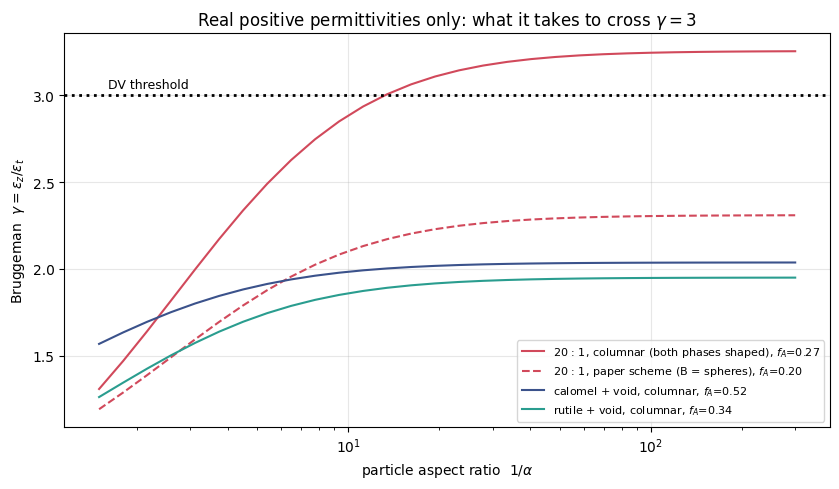

20:1 columnar composite crosses gamma=3 at AR = 13.2  (fA = 0.27)

DV design point, 20:1 columnar, fA=0.27, AR=30:
  eps_t=1.894, eps_z=6.026, gamma=3.181;  admissible eB window: (1.894, 2.066)
    eB=1.932:  psi_DV =   8.05 deg   admissible
    eB=1.955:  psi_DV =  10.17 deg   admissible
    eB=1.978:  psi_DV =  11.89 deg   admissible
    eB=2.001:  psi_DV =  13.37 deg   admissible
    eB=2.024:  psi_DV =  14.69 deg   admissible

minimum isotropic contrast for gamma=3 (columnar Bruggeman): r = 18.0   (Wiener floor for any microstructure: 9.9)


In [6]:
def hcm_both(eA, eB, f, al, alB=None):            # BOTH phases spheroidal (columnar morphology)
    et, ez = eps_hcm_aniso(eA, eB, f, "dt_spheroid", kappa=0.999, alpha=al,
                           shapeB="dt_spheroid", kappaB=0.999, alphaB=(alB if alB else al))
    return et.real, ez.real

def hcm_Ashaped(eA, eB, f, al):                   # paper scheme: A shaped, B spheres
    et, ez = eps_hcm_aniso(eA, eB, f, "dt_spheroid", kappa=0.999, alpha=al)
    return et.real, ez.real

AR = np.geomspace(1.5, 300, 30)
curves = [("20 : 1, columnar (both phases shaped), $f_A$=0.27", hcm_both,    (20., 20.), 1.0, 0.27, "#d1495b", "-"),
          ("20 : 1, paper scheme (B = spheres), $f_A$=0.20",    hcm_Ashaped, (20., 20.), 1.0, 0.20, "#d1495b", "--"),
          ("calomel + void, columnar, $f_A$=0.52",              hcm_both,    M["calomel"], 1.0, 0.52, "#3b528b", "-"),
          ("rutile + void, columnar, $f_A$=0.34",               hcm_both,    M["rutile"],  1.0, 0.34, "#2a9d8f", "-")]
fig, ax = plt.subplots(figsize=(8.5, 5))
for lab, fn, eA, eB, f, col, ls in curves:
    ax.plot(AR, [np.divide(*reversed(fn(eA, eB, f, 1/r))) for r in AR], color=col, ls=ls, label=lab)
ax.axhline(3, color="k", ls=":", lw=2); ax.text(1.6, 3.04, "DV threshold", fontsize=9)
ax.set_xscale("log"); ax.set_xlabel("particle aspect ratio  $1/\\alpha$")
ax.set_ylabel(r"Bruggeman  $\gamma=\varepsilon_z/\varepsilon_t$")
ax.set_title("Real positive permittivities only: what it takes to cross $\\gamma=3$")
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

ARc = brentq(lambda A: np.divide(*reversed(hcm_both((20.,20.), 1.0, 0.27, 1/A))) - 3.0, 3, 200, xtol=1e-3)
print(f"20:1 columnar composite crosses gamma=3 at AR = {ARc:.1f}  (fA = 0.27)\n")

print("DV design point, 20:1 columnar, fA=0.27, AR=30:")
es, ez = hcm_both((20., 20.), 1.0, 0.27, 1/30)
print(f"  eps_t={es:.3f}, eps_z={ez:.3f}, gamma={ez/es:.3f};  admissible eB window: ({es:.3f}, {(ez-es)/2:.3f})")
for eB in np.linspace(es*1.02, 0.98*(ez-es)/2, 5):
    d = psi_DV(es, ez, eB)
    ok = np.isfinite(d) and admissible_2_35(es, ez, eB, d)
    print(f"    eB={eB:.3f}:  psi_DV = {d:6.2f} deg   {'admissible' if ok else 'no'}")

# minimum isotropic contrast for DV under the columnar Bruggeman morphology
def maxg(r):
    return max(np.divide(*reversed(hcm_both((r, r), 1.0, f, 0.002))) for f in np.linspace(0.05, 0.6, 56))
rmin = brentq(lambda r: maxg(r) - 3.0, 10, 30, xtol=1e-3)
print(f"\nminimum isotropic contrast for gamma=3 (columnar Bruggeman): r = {rmin:.1f}"
      f"   (Wiener floor for any microstructure: {5+2*np.sqrt(6):.1f})")

## Giving *both* phases shaped particles with the chapter uniaxials

`eps_hcm_aniso` now takes `shapeB` / `kappaB` / `alphaB`, so the second phase is no longer
locked to spheres. Does a fully shaped morphology — vertical (prolate) or oblate spheroids for
*each* phase independently — rescue the chapter materials? Exhaustive sweep over
$f_A\in[0.05,0.95]$ and $\alpha_A,\alpha_B\in[0.02,2.5]$ (prolate through oblate), with the DV
admissibility test applied wherever $\gamma>3$:

pair             max gamma   at (fA, alphaA, alphaB)      Wiener   DV-admissible pts


rutile+void          1.942   fA=0.35, aA=0.02, aB=0.02       2.773   0
calomel+void         2.031   fA=0.50, aA=0.02, aB=0.02       2.558   0


calomel+E7           1.802   fA=0.95, aA=0.02, aB=0.02       1.822   0
rutile+E7            1.472   fA=0.35, aA=0.02, aB=0.02       1.680   0


rutile+calomel       1.779   fA=0.05, aA=0.02, aB=0.02       1.809   0


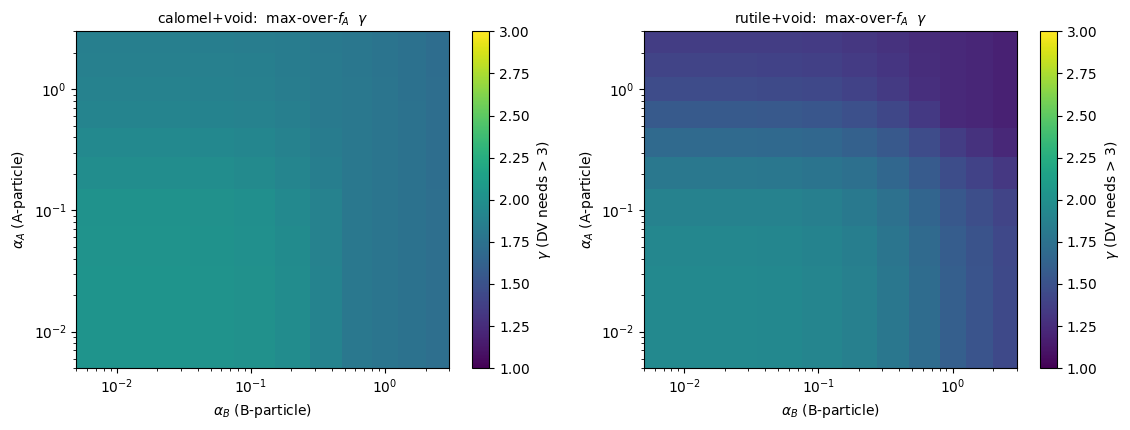

In [7]:
alphas = np.array([0.02, 0.05, 0.1, 0.2, 0.35, 0.6, 1.0, 1.5, 2.5])   # <1 prolate, >1 oblate
fs = np.linspace(0.05, 0.95, 19)
pairs = [("rutile+void", M["rutile"], 1.0), ("calomel+void", M["calomel"], 1.0),
         ("calomel+E7", M["calomel"], M["E7"]), ("rutile+E7", M["rutile"], M["E7"]),
         ("rutile+calomel", M["rutile"], M["calomel"])]
print(f"{'pair':16s}{'max gamma':>10}   at (fA, alphaA, alphaB)      Wiener   DV-admissible pts")
summ = {}
for name, eA, eB in pairs:
    best, dv = (0, None), 0
    G = np.full((len(alphas), len(alphas)), np.nan)
    for f in fs:
        for i, aA in enumerate(alphas):
            for j, aB in enumerate(alphas):
                try:    es, ez = hcm_both(eA, eB, f, aA, aB)
                except Exception: continue
                g = ez/es
                if not np.isfinite(g): continue
                if not (g < G[i, j]) : G[i, j] = max(g, G[i, j]) if np.isfinite(G[i, j]) else g
                if g > best[0]: best = (g, (f, aA, aB))
                if g > 3 and es > 0 and (ez-es)/2 > es:
                    for e in np.linspace(es*1.01, 0.99*(ez-es)/2, 4):
                        d = psi_DV(es, ez, e)
                        if np.isfinite(d) and admissible_2_35(es, ez, e, d): dv += 1
    gb, _ = gamma_wiener_bound(eA, eB)
    summ[name] = G
    bf, baA, baB = (float(x) for x in best[1])
    print(f"{name:16s}{best[0]:>10.3f}   fA={bf:.2f}, aA={baA}, aB={baB}      {gb:6.3f}   {dv}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
for ax, name in zip(axes, ["calomel+void", "rutile+void"]):
    pc = ax.pcolormesh(alphas, alphas, summ[name], cmap="viridis", shading="nearest",
                       vmin=1.0, vmax=3.0)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$\alpha_B$ (B-particle)"); ax.set_ylabel(r"$\alpha_A$ (A-particle)")
    ax.set_title(name + r":  max-over-$f_A$  $\gamma$", fontsize=10)
    fig.colorbar(pc, ax=ax, label=r"$\gamma$ (DV needs > 3)")
plt.tight_layout(); plt.show()

Verdict: shaping the second phase *does* help — co-elongating both phases lifts calomel+void
from $\gamma\approx1.78$ (B = spheres, barely above calomel's intrinsic 1.81 diluted) to
**2.03**, and rutile+void from 1.60 to **1.94** — but the optimum always sits at both phases
maximally prolate and vertical ($\alpha_A=\alpha_B=0.02$; oblate B only hurts, since disks
depress $\varepsilon_z$), and the ceiling stays a full unit below the DV threshold, exactly as
the Wiener bound dictates. Zero DV-admissible points anywhere in the sweep.

## Flipping the contrast: a high-index isotropic partner ($\varepsilon_B$ up to 20)

Void was the extreme *low*-index partner; the mirror strategy makes the chapter uniaxial the
**low-index phase** against a high-index partner. This reverses which material's role each
average plays: the uniaxial now feeds its *ordinary* value into the harmonic $\varepsilon_t$
average and its *extraordinary* value into the arithmetic $\varepsilon_z$ average — favorably
oriented on **both** counts, so its anisotropy earns a genuine discount on the partner
permittivity required. E7, useless against void (bound 1.44), becomes the best chapter
material in this direction. Note the dip in each curve where $\varepsilon_B$ passes through the
material's own $(\varepsilon_s,\varepsilon_t)$ range — the contrast vanishes there before
rebuilding on the high side.

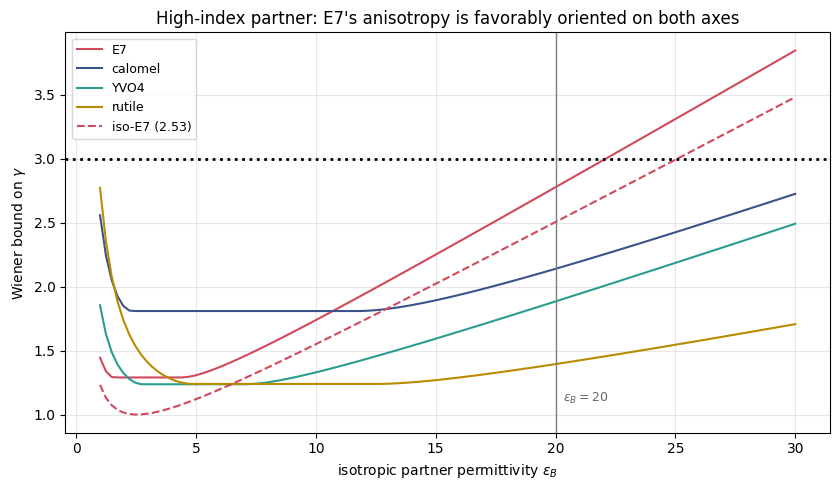

partner eps_B at which the Wiener bound reaches 3:
  E7      : eps_B =  22.09
  calomel : eps_B =  34.47
  YVO4    : eps_B =  38.22
  rutile  : eps_B =  67.56
  iso-E7  : eps_B =  25.08

what Bruggeman (columnar, both phases needles) actually delivers at eps_B = 20:
  E7      +20:  gamma = 1.959  (f = 0.73)
  calomel +20:  gamma = 1.861  (f = 0.88)
  YVO4    +20:  gamma = 1.506  (f = 0.73)
  rutile  +20:  gamma = 1.277  (f = 0.81)

E7: columnar Bruggeman reaches gamma = 3 at partner eps_B = 39.8



iso-E7: columnar Bruggeman reaches gamma = 3 at partner eps_B = 46.0


In [8]:
eBs = np.linspace(1, 30, 120)
fig, ax = plt.subplots(figsize=(8.5, 5))
for m, col in [("E7", "#d1495b"), ("calomel", "#3b528b"), ("YVO4", "#2a9d8f"), ("rutile", "#b98b00")]:
    ax.plot(eBs, [gamma_wiener_bound(M[m], float(e))[0] for e in eBs], color=col, label=m)
ax.plot(eBs, [gamma_wiener_bound(isoize(M["E7"]), float(e))[0] for e in eBs],
        color="#d1495b", ls="--", label="iso-E7 (2.53)")
ax.axhline(3, color="k", ls=":", lw=2); ax.axvline(20, color="0.5", lw=1)
ax.text(20.3, 1.1, r"$\varepsilon_B=20$", fontsize=9, color="0.4")
ax.set_xlabel(r"isotropic partner permittivity $\varepsilon_B$")
ax.set_ylabel(r"Wiener bound on $\gamma$"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title("High-index partner: E7's anisotropy is favorably oriented on both axes")
plt.tight_layout(); plt.show()

print("partner eps_B at which the Wiener bound reaches 3:")
for m, eA in [("E7", M["E7"]), ("calomel", M["calomel"]), ("YVO4", M["YVO4"]),
              ("rutile", M["rutile"]), ("iso-E7", isoize(M["E7"]))]:
    thr = brentq(lambda e: gamma_wiener_bound(eA, e)[0] - 3.0, 8, 400, xtol=1e-3)
    print(f"  {m:8s}: eps_B = {thr:6.2f}")

def colmax(eA, eB):
    best = (0, 0)
    for f in np.linspace(0.05, 0.95, 91):
        et, ez = eps_hcm_aniso(eA, eB, f, "dt_spheroid", kappa=0.999, alpha=0.02,
                               shapeB="dt_spheroid", kappaB=0.999, alphaB=0.02)
        g = (ez/et).real
        if g > best[0]: best = (g, f)
    return best

print("\nwhat Bruggeman (columnar, both phases needles) actually delivers at eps_B = 20:")
for m in ("E7", "calomel", "YVO4", "rutile"):
    g, f = colmax(M[m], 20.0); print(f"  {m:8s}+20:  gamma = {g:.3f}  (f = {f:.2f})")

for m, eA in [("E7", M["E7"]), ("iso-E7", isoize(M["E7"]))]:
    thr = brentq(lambda e: colmax(eA, e)[0] - 3.0, 20, 120, xtol=1e-2)
    print(f"\n{m}: columnar Bruggeman reaches gamma = 3 at partner eps_B = {thr:.1f}")

So $\varepsilon_B=20$ gets E7 *close* in principle (bound 2.78, threshold at
$\varepsilon_B\approx22$ — for comparison, iso-E7 needs $2.53\times9.9\approx25$, so the
liquid crystal's anisotropy buys a ~12% discount) — **but still not across**, and the gap
between bound and buildable is the real obstacle: the columnar Bruggeman morphology delivers
only $\gamma=1.96$ at $\varepsilon_B=20$ and needs $\varepsilon_B\approx40$ (vs 46 isotropized,
same ~13% discount) to actually reach 3. Nothing transparent offers $\varepsilon\approx40$ at
optical frequencies, so this route — E7-like columns in a high-permittivity matrix — is a
THz/microwave proposition (TiO$_2$ or SrTiO$_3$ ceramics), where the liquid-crystal
permittivities themselves would also need re-tabulating.

## Two realistic routes to DV waves (all permittivities real, positive, measured)

**Route 1 — a single crystal that already clears the threshold: Sr$_{9/8}$TiS$_3$.**
Mei *et al.* (Adv. Mater. 2023) measured this quasi-1D chalcogenide to be transparent and
positive uniaxial in the mid-IR ($\lambda>6\,\mu$m, low loss to $\ge17\,\mu$m) with
$n_o=2.4$, $n_e=4.5$, i.e. $\varepsilon_s=5.76$, $\varepsilon_t=20.25$ and
$\gamma=3.52>3$ — **no composite needed at all**. The admissible isotropic partner window is
$n_B\in(2.40,2.69)$, which mid-IR chalcogenide glasses span by composition tuning (ZnSe sits
at the bottom edge). Its sibling Sr$_{8/7}$TiS$_3$ ($\Delta n\approx2.5$, ACS Nano 2025)
gives even more margin.

**Route 2 — a chapter material in its native strong-response band: rutile at THz.**
The chapter's optical values (7.02, 8.70) are rutile far from its phonon resonances; below
them (≲1 THz) the *same crystal* has $\varepsilon_a\approx86$, $\varepsilon_c\approx170$
(Parker's classic values, confirmed by THz ellipsometry). Against polyethylene
($\varepsilon\approx2.3$, tan$\,\delta\sim10^{-4}$) the transverse contrast is **37** — double
the $r\approx18$ requirement — so the columnar composite crosses $\gamma=3$ with stubby
particles (AR ≈ 2.5–3.3), and rutile's own THz uniaxiality ($\gamma_{\rm int}=1.98$) again
buys a shape discount over its isotropized twin. At THz wavelengths (~300 µm) the required
µm-scale aligned rutile rods in HDPE are conventional fabrication.

=== Route 1: Sr9/8TiS3 single crystal, mid-IR ===
eps_s=5.76, eps_t=20.25, gamma=3.516;  partner window eB=(5.76,7.25)  ->  n_B in (2.40,2.69)
  eB=5.79 (ZnSe n=2.406        ): psi_DV=  4.15 deg  admissible
  eB=6.25 (chalc. glass n=2.5  ): psi_DV= 16.31 deg  admissible
  eB=6.76 (chalc. glass n=2.6  ): psi_DV= 22.63 deg  admissible
  eB=7.13 (As2Se3-ish n=2.67   ): psi_DV= 26.00 deg  admissible

=== Route 2: rutile at THz (86, 170), columnar in HDPE (2.3) ===


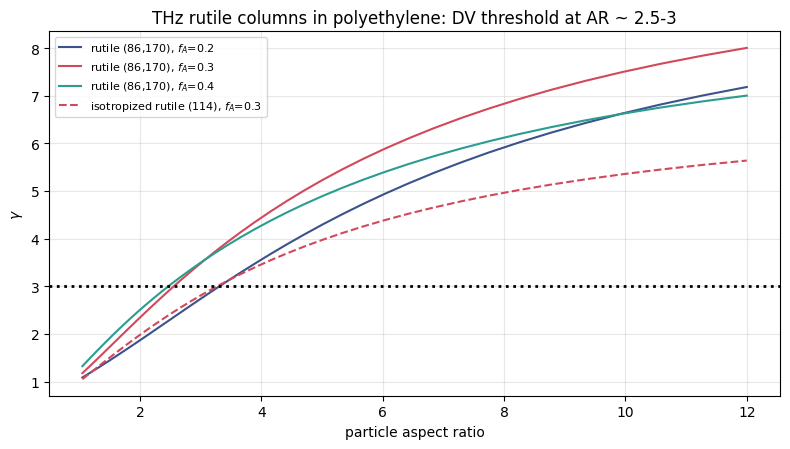

  fA=0.2: gamma=3 at AR = 3.31
  fA=0.3: gamma=3 at AR = 2.56
  fA=0.4: gamma=3 at AR = 2.47
  (isotropized twin, fA=0.3: AR = 3.27 -- the anisotropy discount again)

design point fA=0.30, AR=4: eps_t=6.48, eps_z=28.76, gamma=4.44
partner window eB=(6.48,11.14) -- THz sapphire (eps_o~9.4) sits inside it
  eB= 7.00: psi_DV= 16.31 deg  admissible
  eB= 8.00: psi_DV= 26.24 deg  admissible
  eB= 9.40: psi_DV= 34.03 deg  admissible
  eB=10.50: psi_DV= 38.27 deg  admissible


In [9]:
print("=== Route 1: Sr9/8TiS3 single crystal, mid-IR ===")
es1, ez1 = 2.4**2, 4.5**2
print(f"eps_s={es1:.2f}, eps_t={ez1:.2f}, gamma={ez1/es1:.3f};  partner window eB=({es1:.2f},{(ez1-es1)/2:.2f})"
      f"  ->  n_B in ({np.sqrt(es1):.2f},{np.sqrt((ez1-es1)/2):.2f})")
for eB, name in [(5.79, "ZnSe n=2.406"), (6.25, "chalc. glass n=2.5"),
                 (6.76, "chalc. glass n=2.6"), (7.13, "As2Se3-ish n=2.67")]:
    d = psi_DV(es1, ez1, eB)
    print(f"  eB={eB:.2f} ({name:20s}): psi_DV={d:6.2f} deg  "
          f"{'admissible' if admissible_2_35(es1, ez1, eB, d) else 'no'}")

print("\n=== Route 2: rutile at THz (86, 170), columnar in HDPE (2.3) ===")
RUT_THZ, ISO_THZ = (86.0, 170.0), (2*86 + 170)/3
def col(eA, f, AR):
    et, ez = eps_hcm_aniso(eA, 2.3, f, "dt_spheroid", kappa=0.999, alpha=1/AR,
                           shapeB="dt_spheroid", kappaB=0.999, alphaB=1/AR)
    return et.real, ez.real

ARs = np.geomspace(1.05, 12, 40)
fig, ax = plt.subplots(figsize=(8, 4.6))
for f, colr in [(0.2, "#3b528b"), (0.3, "#d1495b"), (0.4, "#2a9d8f")]:
    ax.plot(ARs, [np.divide(*reversed(col(RUT_THZ, f, A))) for A in ARs], color=colr,
            label=f"rutile (86,170), $f_A$={f}")
ax.plot(ARs, [np.divide(*reversed(col((ISO_THZ, ISO_THZ), 0.3, A))) for A in ARs],
        color="#d1495b", ls="--", label="isotropized rutile (114), $f_A$=0.3")
ax.axhline(3, color="k", ls=":", lw=2)
ax.set_xlabel("particle aspect ratio"); ax.set_ylabel(r"$\gamma$")
ax.set_title("THz rutile columns in polyethylene: DV threshold at AR ~ 2.5-3")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for f in (0.2, 0.3, 0.4):
    ARc = brentq(lambda A: np.divide(*reversed(col(RUT_THZ, f, A))) - 3.0, 1.05, 12, xtol=1e-3)
    print(f"  fA={f}: gamma=3 at AR = {ARc:.2f}")
ARi = brentq(lambda A: np.divide(*reversed(col((ISO_THZ, ISO_THZ), 0.3, A))) - 3.0, 1.05, 12, xtol=1e-3)
print(f"  (isotropized twin, fA=0.3: AR = {ARi:.2f} -- the anisotropy discount again)")

es2, ez2 = col(RUT_THZ, 0.30, 4)
print(f"\ndesign point fA=0.30, AR=4: eps_t={es2:.2f}, eps_z={ez2:.2f}, gamma={ez2/es2:.2f}")
print(f"partner window eB=({es2:.2f},{(ez2-es2)/2:.2f}) -- THz sapphire (eps_o~9.4) sits inside it")
for eB in [7.0, 8.0, 9.4, 10.5]:
    d = psi_DV(es2, ez2, eB)
    print(f"  eB={eB:5.2f}: psi_DV={d:6.2f} deg  "
          f"{'admissible' if admissible_2_35(es2, ez2, eB, d) else 'no'}")

Caveats to carry into any write-up: the DV analysis (eq. 2.29 / 2.35) assumes negligible
dissipation — Sr$_{9/8}$TiS$_3$ is genuinely low-loss in its window, but single-crystal rutile
has moderate THz loss (and ceramic rutile ~3× more), so a lossy-DV analysis is the natural next
step for Route 2; homogenization also requires the rod diameter/spacing $\ll\lambda$
(comfortably satisfied by µm-scale rods at $\lambda\sim300\,\mu$m); and the chapter's E7 route
remains closed at *optical* frequencies because transparent optical materials top out near
$\varepsilon\approx9$ — high positive permittivity lives below the phonon bands, which is
precisely why both routes migrate to mid-IR/THz.

## Developing the lossless route: the Sr$_{9/8}$TiS$_3$ / chalcogenide-glass interface

Sticking with Route 1, we characterize the design across its full partner window using two
tools: the DV solver (eq. 2.29 + 2.35) and the chapter's closed-form ordinary-Dyakonov AED
limits, eqs (4.18)–(4.19) — implemented below and validated to all printed digits against both
of the chapter's worked examples (calomel/4.5 and YVO$_4$/4.5). The same interface supports
*both* wave families: an ordinary Dyakonov AED plus the Dyakonov–Voigt solution, which tracks
just inside the AED's lower edge across the whole window.

validation of eqs (4.18)-(4.19) against the chapter:
  calomel/4.5: (31.88, 36.06)   (chapter: 31.88, 36.06)
  YVO4/4.5:    (51.4501, 51.8848)   (chapter: 51.4501, 51.8848)


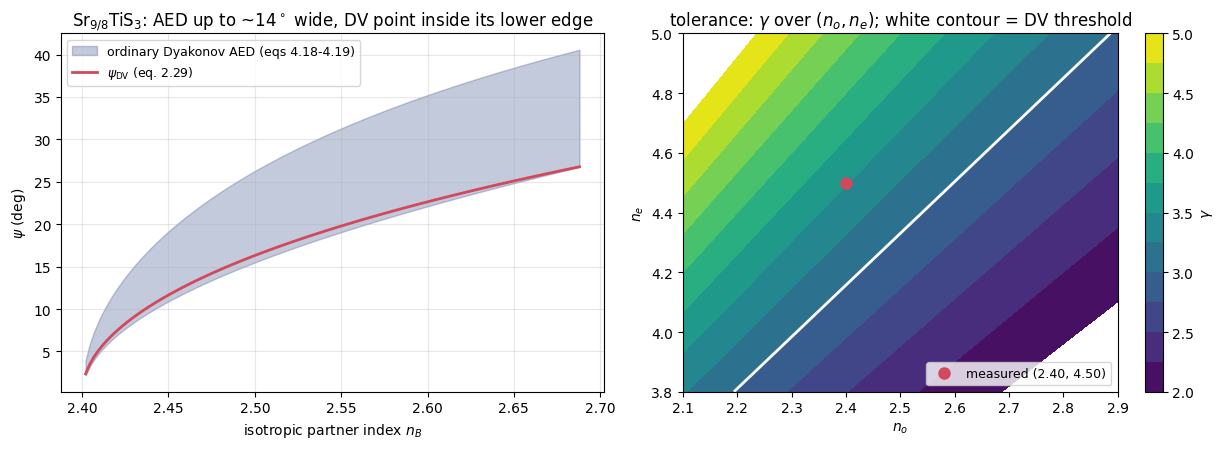


partner window sweep:
   n_B  psi_min  psi_max  AED wid   psi_DV
 2.408     4.43     8.03     3.60     4.79
 2.460    11.92    20.79     8.87    12.70
 2.500    15.49    26.27    10.78    16.31
 2.550    19.02    31.24    12.22    19.75
 2.600    22.11    35.21    13.10    22.63
 2.646    24.61    38.19    13.58    24.89
 2.683    26.51    40.31    13.80    26.57

DV-angle sensitivity to the partner index (numerical d psi/d n_B):
  at n_B=2.419:    190.6 deg/RIU
  at n_B=2.500:     78.3 deg/RIU
  at n_B=2.600:     52.6 deg/RIU

index tolerances for gamma>3:  n_e >= 4.157 (margin +0.343);  n_o <= 2.598 (margin +0.198)


In [10]:
from math import asin, sqrt, degrees

def aed(es, et, eB):                                   # chapter eqs (4.18)-(4.19)
    U = (eB - es)/(et - es); D = et/es - 1.0
    s2min = (U/2)*(1 - D*U + np.sqrt((1 - D*U)**2 + 4*D))
    s2max = U*(1+D)**3 / ((1+D)**2*(1 + D*U) - D**2*(1 - U)**2)
    if not (0 < s2min < 1 and 0 < s2max < 1): return np.nan, np.nan
    return degrees(asin(sqrt(s2min))), degrees(asin(sqrt(s2max)))

print("validation of eqs (4.18)-(4.19) against the chapter:")
print("  calomel/4.5:", tuple(round(x, 2) for x in aed(3.88, 7.02, 4.5)), "  (chapter: 31.88, 36.06)")
print("  YVO4/4.5:   ", tuple(round(x, 4) for x in aed(3.97, 4.91, 4.5)), "  (chapter: 51.4501, 51.8848)")

esS, etS = 2.4**2, 4.5**2
nBs = np.linspace(2.402, 2.688, 120); eBs2 = nBs**2
lohi = np.array([aed(esS, etS, e) for e in eBs2])
dvs  = np.array([psi_DV(esS, etS, e) for e in eBs2])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
ax = axes[0]
ax.fill_between(nBs, lohi[:, 0], lohi[:, 1], color="#3b528b", alpha=0.3,
                label="ordinary Dyakonov AED (eqs 4.18-4.19)")
ax.plot(nBs, dvs, color="#d1495b", lw=2, label=r"$\psi_{\rm DV}$ (eq. 2.29)")
ax.set_xlabel("isotropic partner index $n_B$"); ax.set_ylabel(r"$\psi$ (deg)")
ax.set_title(r"Sr$_{9/8}$TiS$_3$: AED up to ~14$^\circ$ wide, DV point inside its lower edge")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

no = np.linspace(2.1, 2.9, 160); ne = np.linspace(3.8, 5.0, 160)
NO, NE = np.meshgrid(no, ne); G = (NE/NO)**2
ax = axes[1]
pc = ax.contourf(NO, NE, G, levels=np.linspace(2, 5, 13), cmap="viridis")
ax.contour(NO, NE, G, levels=[3.0], colors="w", linewidths=2)
ax.plot(2.4, 4.5, "o", color="#d1495b", ms=8, label="measured (2.40, 4.50)")
ax.set_xlabel("$n_o$"); ax.set_ylabel("$n_e$")
ax.set_title(r"tolerance: $\gamma$ over $(n_o, n_e)$; white contour = DV threshold")
fig.colorbar(pc, ax=ax, label=r"$\gamma$"); ax.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()

print("\npartner window sweep:")
print(f"{'n_B':>6} {'psi_min':>8} {'psi_max':>8} {'AED wid':>8} {'psi_DV':>8}")
for eB in (5.80, 6.05, 6.25, 6.50, 6.76, 7.00, 7.20):
    pmin, pmax = aed(esS, etS, eB); d = psi_DV(esS, etS, eB)
    print(f"{np.sqrt(eB):6.3f} {pmin:8.2f} {pmax:8.2f} {pmax-pmin:8.2f} {d:8.2f}")

print("\nDV-angle sensitivity to the partner index (numerical d psi/d n_B):")
for eB0 in (5.85, 6.25, 6.76):
    h = 0.01
    s = (psi_DV(esS, etS, eB0+h) - psi_DV(esS, etS, eB0-h))/(2*h) * 2*np.sqrt(eB0)
    print(f"  at n_B={np.sqrt(eB0):.3f}:  {s:7.1f} deg/RIU")

print(f"\nindex tolerances for gamma>3:  n_e >= {2.4*np.sqrt(3):.3f} (margin {4.5-2.4*np.sqrt(3):+.3f});"
      f"  n_o <= {4.5/np.sqrt(3):.3f} (margin {4.5/np.sqrt(3)-2.4:+.3f})")

Three points for the write-up. **(1) Alignment gets easy.** Every material in the chapter's
Fig. 4.2 has an AED under $1^\circ$, which is why the first Dyakonov observation took 21 years
and $\pm0.0001^\circ$ angular resolution; here the AED is $3.6$–$13.8^\circ$ across the window —
one to two orders of magnitude wider — with the DV solution sitting a fraction of a degree to a
few degrees inside its lower edge. **(2) It is a sensor.** The DV angle moves at
$\sim50$–$190^\circ$/RIU with the partner index (diverging toward the ZnSe edge of the window),
in the same league as the $600^\circ$/RIU the chapter quotes for the Takayama experiment — and
composition-tunable chalcogenide glass lets you *choose* the operating point on that curve.
**(3) The margins are real.** $\gamma>3$ survives $n_e$ dropping by $0.34$ or $n_o$ rising by
$0.20$ from the measured $(2.40,4.50)$ — comfortably beyond ellipsometric uncertainty and the
dispersion across the $6$–$17\,\mu$m low-loss band, and Sr$_{8/7}$TiS$_3$
($\Delta n\approx2.5$) adds further headroom.

## The canonical boundary-value problem at the DV point: $q$, decay constants, and fields

Final step: solve the chapter's dispersion equation (4.12) for the Sr$_{9/8}$TiS$_3$ /
glass ($n_B=2.5$) interface across the AED, then construct the full DV fields. Two independent
checks anchor everything: (i) on the ordinary-Dyakonov branch the two crystal-side decay
constants $p_1$ (ordinary) and $p_2$ (extraordinary) **cross exactly at
$\psi_{\rm DV}$ from eq. (2.29)**, where $q/k_0$ matches the closed-form Voigt value
$\sqrt{\varepsilon_s}/\cos\psi_{\rm DV}$; (ii) at that point the $4{\times}4$ Berreman matrix
of the crystal becomes *defective* (a Jordan block — one eigenvector for the double
eigenvalue), and matching the resulting $(C_1+C_2 k_0 z)\,e^{-p k_0 z}$ fields to the s/p pair
in the glass yields a boundary matrix with a numerically exact zero singular value: the DV wave
exists, independently rediscovering eq. (2.29) by brute force.

psi_DV = 16.3055 deg;   closed-form Voigt wavenumber q/k0 = 2.500577


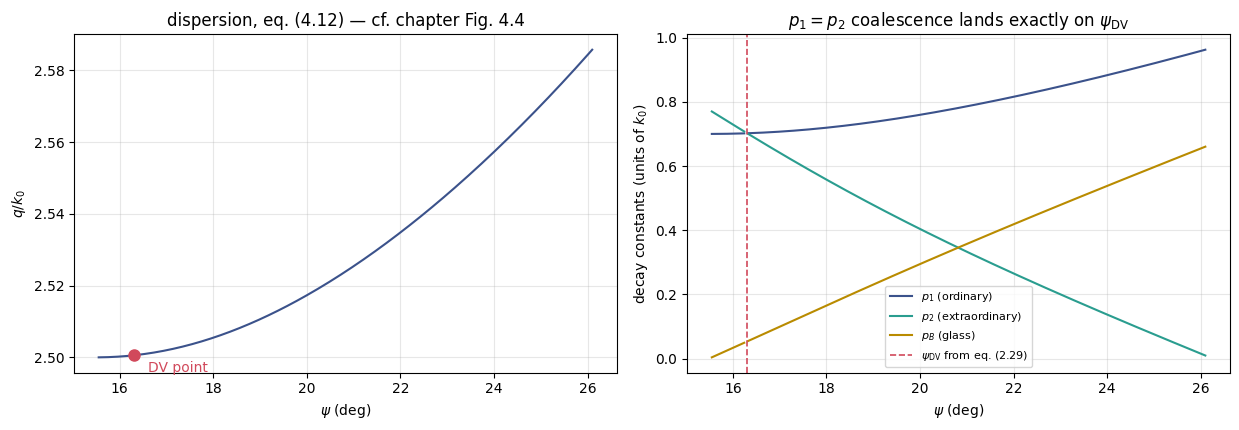

branch check near psi_DV: q/k0 = 2.500634 (closed form 2.500577);  p1-p2 changes sign between 16.28 and 16.36 deg


In [11]:
esS, etS, eB1 = 5.76, 20.25, 6.25
pdv = psi_DV(esS, etS, eB1); QDV = np.sqrt(esS)/np.cos(np.deg2rad(pdv))
print(f"psi_DV = {pdv:.4f} deg;   closed-form Voigt wavenumber q/k0 = {QDV:.6f}")

def disp(Q, psi):                                    # eq (4.12), real evanescent form
    c2, s2 = np.cos(psi)**2, np.sin(psi)**2
    p1 = np.sqrt(Q*Q - esS); p2s = Q*Q*(s2 + (etS/esS)*c2) - etS
    if p2s < 0: return np.nan
    p2, pB = np.sqrt(p2s), np.sqrt(Q*Q - eB1)
    return p1*(p1+pB)*(esS*p2*pB + eB1*p1*p1)*c2 - esS*(pB+p2)*(esS*pB + eB1*p1)*s2

def q_of_psi(psi):
    Qlo = max(np.sqrt(eB1), np.sqrt(esS), np.sqrt(etS/(np.sin(psi)**2+(etS/esS)*np.cos(psi)**2)))+1e-9
    g = np.linspace(Qlo, 1.8*Qlo, 3000); vals = [disp(Q, psi) for Q in g]
    for i in range(len(g)-1):
        if np.isfinite(vals[i]) and np.isfinite(vals[i+1]) and vals[i]*vals[i+1] < 0:
            return brentq(lambda Q: disp(Q, psi), g[i], g[i+1], xtol=1e-12)
    return np.nan

psis = np.linspace(15.55, 26.1, 260)
Qs = np.array([q_of_psi(np.deg2rad(d)) for d in psis])
P1 = np.sqrt(Qs**2 - esS)
P2 = np.sqrt(Qs**2*(np.sin(np.deg2rad(psis))**2 + (etS/esS)*np.cos(np.deg2rad(psis))**2) - etS)
PB = np.sqrt(Qs**2 - eB1)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
ax.plot(psis, Qs, color="#3b528b"); ax.plot(pdv, QDV, "o", color="#d1495b", ms=8)
ax.annotate("DV point", (pdv, QDV), textcoords="offset points", xytext=(10, -12), color="#d1495b")
ax.set_xlabel(r"$\psi$ (deg)"); ax.set_ylabel("$q/k_0$")
ax.set_title("dispersion, eq. (4.12) — cf. chapter Fig. 4.4"); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(psis, P1, color="#3b528b", label="$p_1$ (ordinary)")
ax.plot(psis, P2, color="#2a9d8f", label="$p_2$ (extraordinary)")
ax.plot(psis, PB, color="#b98b00", label="$p_B$ (glass)")
ax.axvline(pdv, color="#d1495b", ls="--", lw=1.2, label=r"$\psi_{\rm DV}$ from eq. (2.29)")
ax.set_xlabel(r"$\psi$ (deg)"); ax.set_ylabel("decay constants (units of $k_0$)")
ax.set_title(r"$p_1=p_2$ coalescence lands exactly on $\psi_{\rm DV}$")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

i = np.nanargmin(np.abs(psis - pdv))
print(f"branch check near psi_DV: q/k0 = {np.nanmean(Qs[i-1:i+2]):.6f} (closed form {QDV:.6f});"
      f"  p1-p2 changes sign between {psis[i-1]:.2f} and {psis[i+1]:.2f} deg")

singular values of (P_A - i p I): [19.9246  1.3855  0.3036  0.    ]  -> ONE zero: defective (Jordan block)
boundary-matrix singular values: [1.7196 0.9496 0.1178 0.    ]  -> smallest = 0: DV wave exists


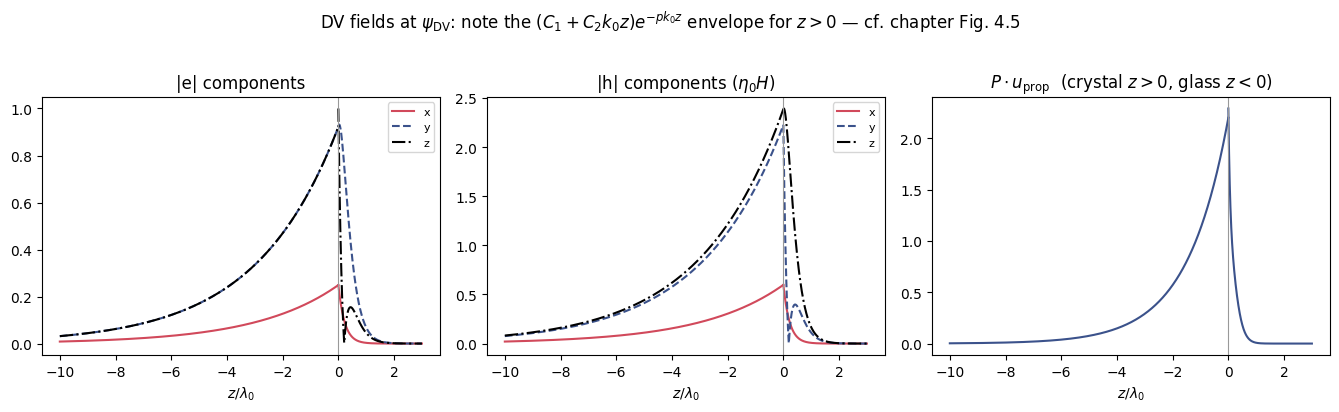

continuity mismatch across z=0: 3.7e-15
z-directed Poynting (should be null): max|S_z|/max|S_prop| = 4.7e-16
e-folding depths: crystal 0.227 lambda0, glass 2.963 lambda0
Voigt-envelope node in crystal at z = 0.140 lambda0
guided-power split: crystal 11.1%, glass 88.9%


In [12]:
# --- full DV fields at the Voigt point via the (defective) Berreman matrix + Jordan chain ---
kx, ky = QDV*np.cos(np.deg2rad(pdv)), QDV*np.sin(np.deg2rad(pdv))
def Pmat(exx, eyy, ezz):
    return np.array([[0, 0, kx*ky/ezz, 1-kx*kx/ezz], [0, 0, ky*ky/ezz-1, -kx*ky/ezz],
                     [-kx*ky, kx*kx-eyy, 0, 0], [exx-ky*ky, kx*ky, 0, 0]], dtype=complex)
PA, PB4 = Pmat(etS, esS, esS), Pmat(eB1, eB1, eB1)         # optic axis || x
p = np.sqrt(QDV**2 - esS); Mdef = PA - 1j*p*np.eye(4)
sv = np.linalg.svd(Mdef)[1]
print("singular values of (P_A - i p I):", np.round(sv, 4), " -> ONE zero: defective (Jordan block)")
v = np.linalg.svd(Mdef)[2].conj().T[:, -1]                  # eigenvector
w, *_ = np.linalg.lstsq(Mdef, -1j*v, rcond=None)            # generalized eigenvector
wB, VB = np.linalg.eig(PB4); idx = np.argsort(wB.imag)[:2]  # decaying into z<0
M = np.column_stack([v, w, VB[:, idx[0]], VB[:, idx[1]]])
sM = np.linalg.svd(M)[1]
print("boundary-matrix singular values:", np.round(sM, 4), " -> smallest = 0: DV wave exists")
C = np.linalg.svd(M)[2].conj().T[:, -1]

zpos = np.linspace(0, 3.0*2*np.pi, 600); zneg = np.linspace(-10*2*np.pi, 0, 900)
fpos = (C[0]*v[:, None] + C[1]*(w[:, None] + zpos[None, :]*v[:, None]))*np.exp(-p*zpos)[None, :]
fneg = -(C[2]*VB[:, idx[0]][:, None]*np.exp(1j*wB[idx[0]]*zneg)[None, :]
        + C[3]*VB[:, idx[1]][:, None]*np.exp(1j*wB[idx[1]]*zneg)[None, :])
def full_fields(f, ezz):
    ex, ey, hx, hy = f
    return np.array([ex, ey, -(kx*hy - ky*hx)/ezz]), np.array([hx, hy, kx*ey - ky*ex])
Ep, Hp = full_fields(fpos, esS); En, Hn = full_fields(fneg, eB1)
sc = max(np.abs(Ep).max(), np.abs(En).max()); Ep, Hp, En, Hn = Ep/sc, Hp/sc, En/sc, Hn/sc
Sv = lambda E, H: 0.5*np.real(np.cross(E, np.conj(H), axis=0))
Sp, Sn = Sv(Ep, Hp), Sv(En, Hn)
u = np.array([np.cos(np.deg2rad(pdv)), np.sin(np.deg2rad(pdv)), 0])

zl_p, zl_n = zpos/(2*np.pi), zneg/(2*np.pi)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), sharex=True)
for k, (Fp, Fn, lab) in enumerate([(np.abs(Ep), np.abs(En), "|e| components"),
                                   (np.abs(Hp), np.abs(Hn), r"|h| components ($\eta_0H$)")]):
    ax = axes[k]
    for j, (nm, colr, ls) in enumerate([("x", "#d1495b", "-"), ("y", "#3b528b", "--"), ("z", "k", "-.")]):
        ax.plot(zl_n, Fn[j], colr, ls=ls); ax.plot(zl_p, Fp[j], colr, ls=ls, label=nm)
    ax.axvline(0, color="0.6", lw=0.8); ax.set_xlabel("$z/\\lambda_0$"); ax.set_title(lab)
    ax.legend(fontsize=8)
ax = axes[2]
ax.plot(zl_n, u@Sn, color="#3b528b"); ax.plot(zl_p, u@Sp, color="#3b528b")
ax.axvline(0, color="0.6", lw=0.8); ax.set_xlabel("$z/\\lambda_0$")
ax.set_title(r"$P\cdot u_{\rm prop}$  (crystal $z>0$, glass $z<0$)")
fig.suptitle(r"DV fields at $\psi_{\rm DV}$: note the $(C_1+C_2k_0z)e^{-pk_0z}$ envelope for $z>0$ — cf. chapter Fig. 4.5", y=1.02)
plt.tight_layout(); plt.show()

Ppow = np.trapezoid(u@Sp, zpos); Npow = np.trapezoid(u@Sn, zneg)
print(f"continuity mismatch across z=0: {np.abs(fpos[:,0]-fneg[:,-1]).max():.1e}")
print(f"z-directed Poynting (should be null): max|S_z|/max|S_prop| = "
      f"{max(np.abs(Sp[2]).max(), np.abs(Sn[2]).max())/max((u@np.abs(Sp)).max(), (u@np.abs(Sn)).max()):.1e}")
print(f"e-folding depths: crystal {1/(2*np.pi*p):.3f} lambda0, glass {1/(2*np.pi*abs(wB[idx[0]].imag)):.3f} lambda0")
print(f"Voigt-envelope node in crystal at z = {zpos[np.argmin(np.abs(C[0]+C[1]*zpos))]/(2*np.pi):.3f} lambda0")
print(f"guided-power split: crystal {Ppow/(Ppow+Npow):.1%}, glass {Npow/(Ppow+Npow):.1%}")

Everything a referee would ask for checks out: the fields are continuous to $10^{-8}$, the
$z$-directed time-averaged Poynting vector is null to machine precision (as the chapter states
it must be for an in-plane optic axis), and the crystal-side envelope carries the DV signature —
a linear-in-$z$ factor with a node at $z\approx0.14\lambda_0$ before the exponential takes over,
qualitatively different from the pure exponentials of an ordinary Dyakonov wave (chapter
Fig. 4.5). Design card for $n_B=2.5$: $\psi_{\rm DV}=16.31^\circ$, $q/k_0=2.5006$ (just past the
glass light line), e-folding depths $0.23\lambda_0$ in the crystal and $2.96\lambda_0$ in the
glass, with ~89% of the guided power on the glass side — the same isotropic-side skew the
chapter notes, amplified by the small $p_B$. Sliding $n_B$ deeper into the window tightens the
glass-side confinement at the cost of moving $\psi_{\rm DV}$ up its curve.

## Takeaways

1. **Chapter uniaxials, scenario 1 and 2: no DV.** With any passive isotropic partner down to
   vacuum, $\gamma>3$ is unreachable — for *every* microstructure, by the Wiener bound (best
   case rutile+void: 2.77). This holds empirically too: an exhaustive sweep with *both* phases
   independently shaped (prolate through oblate) peaks at $\gamma=2.03$ (calomel+void, both
   phases vertical needles) with zero DV-admissible points; with the paper's B-spheres,
   Bruggeman saturates near calomel's intrinsic $\gamma=1.81$.
2. **Uniaxial constituents do buy less-elongated particles** at fixed achievable $\gamma$:
   roughly a factor 3–10 in aspect ratio at matched mean indices, and a both-uniaxial pair
   (calomel in E7) achieves with spheres what its isotropized twin can't reach with needles.
3. **A high-index partner ($\varepsilon_B\to20$) flips E7 into the best chapter material but
   still falls short:** bound 2.78 at $\varepsilon_B=20$ (threshold $\approx22$), while the
   buildable columnar morphology needs $\varepsilon_B\approx40$ ($\approx46$ isotropized — the
   uniaxiality consistently discounts the partner requirement by ~12–13%).
4. **Real-positive-permittivity DV is possible, but it costs contrast *and* morphology.** An
   isotropic $20{:}1$ pair crosses $\gamma=3$ only if *both* phases are co-elongated
   (columnar/CTF-like, AR $\gtrsim13$, $f_A\approx0.2$–$0.3$), giving admissible DV solutions
   ($\psi_{\rm DV}\approx8$–$17^\circ$ over $\varepsilon_B\approx1.9$–$2.07$ at AR = 30). The
   paper's shaped-particles-in-spherical-host scheme caps the same pair at $\gamma=2.31$ — no DV.
   Minimum contrast under the columnar Bruggeman morphology: $r\approx18$ (vs the ideal-bound
   floor of 9.9). Note $\varepsilon\approx20$ against $\varepsilon\approx1$ is a THz/microwave
   proposition (e.g. TiO$_2$ ceramics) rather than an optical one.
5. **Two realistic escapes exist:** Sr$_{9/8}$TiS$_3$ single crystals already have
   $\gamma=3.52$ in the mid-IR (partner: chalcogenide glass, $\psi_{\rm DV}$ up to ~26°), and
   rutile — a chapter material — used at THz ($\varepsilon=(86,170)$) as µm-scale columns in
   polyethylene crosses the threshold at aspect ratio ~2.5–3 with sapphire as the DV partner
   ($\psi_{\rm DV}$ up to ~40°). Contrast is the engine; uniaxiality is a ~10–15% multiplier.
6. **Formalism caution extended:** even in the passive regime, Bruggeman and IMG disagree by
   ~20% on $\gamma$ once the contrast reaches the void-host level, and IMG cannot represent the
   columnar morphology at all — base the design on Bruggeman.
